<a href="https://colab.research.google.com/github/Pobesok/Heart-Disease-Predictor/blob/main/1_Capstone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Through the Lens of Truth: Analyzing and Detecting Fake News

## About the organization

![TruthLens](https://drive.google.com/uc?export=view&id=1BSdTj6PVZwEnSCqucDa5DVHUGcPV_6jK)

The TruthLens Institute is a pioneering research organization dedicated to combating misinformation and fostering digital literacy worldwide. Founded in 2015 by a coalition of data scientists, journalists, and social researchers, TruthLens focuses on leveraging cutting-edge technology and interdisciplinary approaches to address the growing challenges of fake news, biased reporting, and disinformation campaigns.

### Mission:

To empower individuals and organizations with tools, insights, and strategies to identify and mitigate the spread of false or misleading information.

### Core Focus Areas:

- Data-Driven Research: Analyzing large datasets to uncover patterns and trends in misinformation.
- Technology Development: Creating AI-driven solutions to detect and counteract fake news in real time.
- Public Education: Offering workshops, webinars, and toolkits to enhance critical thinking and digital literacy.
- Policy Advocacy: Collaborating with governments and tech companies to implement ethical frameworks for content moderation.

### Impact:

Over the years, TruthLens has partnered with global organizations like the United Nations, educational institutions, and social media platforms to amplify its efforts. Their groundbreaking studies have shaped public discourse and influenced policymaking in the realm of digital ethics and media integrity.

**Why the Name "TruthLens"?**

The name reflects the organization’s mission to provide a clear, unbiased lens through which to view the information landscape. By filtering out noise and highlighting the truth, the institute aims to restore trust in media and information ecosystems.

## Project Introduction

As part of your commitments to making the world a better place, you volunteer 8-10 hours a week as a data scientist for a research organization, TruthLens to help in tackling misinformation and understanding its viral nature. Your mission is to analyze a dataset containing text and metadata from websites tagged as fake or biased news sources. This project allows you to explore real-world data challenges, build detection models, and develop actionable insights to combat misinformation.

This project focuses on exploring, cleaning, and analyzing a dataset containing text and metadata scraped from 244 websites. You will also build predictive models to detect fake or biased content using natural language processing (NLP) and metadata features. The dataset contains 12,999 posts from the last 30 days, providing a rich resource for analysis.

In addition to technical skills, you will also reflect on the nuances of detecting misinformation, the ethical challenges of labeling data, and potential improvements for the dataset.

## Objectives

The main objectives of this project are:

- Data Exploration: Understand the structure, distribution, and nuances of the dataset.
- Data Cleaning: Handle missing or inconsistent labels and clean text data for analysis.
- Feature Engineering: Extract meaningful features from both text and metadata.
- Model Development: Build and evaluate machine learning models to detect fake or biased news.
- Insights and Recommendations: Provide actionable insights and propose potential improvements for misinformation detection systems.

## About the dataset

The dataset contains:

- Text Data: Articles or posts from websites.
- Metadata: Information such as timestamps, URLs, and labels (e.g., "bs").
- Labels: Predefined tags from the BS Detector extension indicating the type of fake or biased content.

**You would find the dataset at: "[fake_or_real_news.csv](https://drive.google.com/file/d/1m1gRCISgJr0W2TiveQxCxOyw6G9Yiwkj/view?usp=sharing)"**

## Task

**Phase 1: Data Exploration and Cleaning**

- Load the dataset and examine its structure (e.g., columns, data types, missing values, remove unnecessary columns).
- Preprocess the text data (e.g., remove stopwords, punctuations, and perform tokenization).

**Phase 2: Feature Engineering**

- Extract key features from the text, such as word count, sentiment, and term frequency. You can generate a word cloud for frequently occurring terms in fake news articles.
- Extract metadata-based features (e.g., domain, publication time patterns). Consider identifying if specific domains contribute more fake news than others.

**Phase 3: Model Development**

- Split the data into training and test sets, ensuring balanced distribution of labels.
- Use NLP techniques (e.g., TF-IDF, embeddings) to represent the text data, and compare the performance of different models
- Evaluate model performance using appropriate metrics (e.g., accuracy, F1-score).

**Phase 4: Insights and Recommendations**

- Analyze the results and discuss the model's strengths and weaknesses and write a summary of key insights from the model and the dataset.
- Propose ethical considerations and improvements for detecting misinformation. Suggest additional features or external data sources that could enhance model performance.

## Deliverables

- Exploratory Data Analysis (EDA) notebook with visualizations and data cleaning steps. (3 weeks) --> Jupyter notebook
- An organized Jupyter Notebook detailing necessary project phases (2 weeks) --> Jupyter notebook
- Detailed documentation of the entire workflow, insights, and recommendations, including challenges faced and solutions implemented. (2 weeks) --> Microsoft word document or pdf file format

**Timeline = 7 weeks.**

**EXECUTIVE SUMMARY**
The objective of this project was to develop a machine learning model capable of accurately detecting fake news using a balanced dataset of real and fake news articles. The data underwent a thorough cleaning process, which involved removing duplicate entries, stopwords, and punctuation, as well as converting all text to lowercase. The cleaned text was then transformed into numerical format using the TF-IDF vectorization technique. Three models—Logistic Regression, Random Forest, and Support Vector Machine (SVM)—were trained and evaluated. SVM achieved the highest initial accuracy of 92.08%. However, after hyperparameter tuning, Logistic Regression outperformed the others and was selected for future deployment. The analysis also identified key distinguishing terms between fake and real news, offering valuable insights into linguistic patterns. Several ethical concerns were highlighted, including the potential for data bias, suppression of minority or dissenting voices, removal of legitimate content, and the risk of echo chambers. Key recommendations include leveraging metadata features such as publication time, source reliability scores, and engagement metrics; incorporating user feedback to improve model transparency; and implementing robust strategies to mitigate bias in future iterations. A major challenge encountered was the poor structure of the dataset despite its CSV format, which complicated the data preparation phase. Edited: chatgpt

A.  DATA DOWNLOAD AND INSPECTION

Load Dataset

In [ ]:
# Import relevant library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from nltk.corpus import stopwords

# Load dataset from Google Drive link
google_drive_link = "https://drive.google.com/file/d/1m1gRCISgJr0W2TiveQxCxOyw6G9Yiwkj/view?usp=sharing"
file_id = google_drive_link.split('/')[-2]
direct_download_link = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(direct_download_link)

df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
# Select the desired columns by name
df = df[['title', 'text', 'label']]

display(df.head())

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
#  Checking the Label column Distribution
label_distribution = df['label'].value_counts()

print("Distribution of Fake vs. Real News:")
display(label_distribution)

# You can also display the distribution as a percentage
print("\nDistribution as Percentage:")
display(df['label'].value_counts(normalize=True) * 100)

Distribution of Fake vs. Real News:


,count
label,
REAL,3171
FAKE,3164



Distribution as Percentage:


,proportion
label,
REAL,50.055249
FAKE,49.944751


A view of distribution of Raw data before cleaning indicates that the distribution betweed 'Fake' and 'Real' news are balanced- very nearly 50-50

In [ ]:
df.isnull().sum()

,0
title,0
text,0
label,0


No missing values

In [ ]:
df.describe()

,title,text,label
count,6335,6335,6335
unique,6256,6060,2
top,OnPolitics | 's politics blog,"Killing Obama administration rules, dismantlin...",REAL
freq,5,58,3171


All three columns ('title', 'text', and 'label') have 6335 entries, meaning there are no missing values in these columns.
'title' has 6256 unique titles, implying that some titles might be repeated are or very similar.
6060 unique text entries, indicating there are some duplicate articles or posts in the dataset.
'label' has only 2 unique values, which are 'FAKE' and 'REAL', as we expect for a binary classification task.
f.	top:indicates tha:
i.	The most frequent title is 'OnPolitics | 's politics blog'.
ii.	The most frequent text entry is related to 'Killing Obama administration rules...'.
iii.	The most frequent label is 'REAL'.



Checking and removing duplicate posts or articles

In [ ]:
# Check for duplicate posts and articles based on 'Text'
initial_rows = len(df)
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Initial number of rows: {initial_rows}")

# Remove duplicate rows based on the 'text' column, keeping the first column
df_cleaned = df.drop_duplicates(subset=['text'], keep='first').copy()

# Verify the number of rows after removing duplicates
rows_after_removing_duplicates = len(df_cleaned)
print(f"Number of rows after removing duplicates: {rows_after_removing_duplicates}")

# Display the shape of new DataFrame
print("shape of DataFrame after removing duplicates", df_cleaned.shape)

Number of duplicate rows: 29
Initial number of rows: 6335
Number of rows after removing duplicates: 6060
shape of DataFrame after removing duplicates (6060, 3)


Removing duplicates based solely on the 'text' column resulted in a larger reduction (6335 - 6060 = 275 fewer rows compared to the original dataset), indicating there were many instances where only the text content was identical, but other columns might have varied.

2. Cleaning and Preprocessing

In [ ]:
# Import relevant NLP libraries
import nltk
import re
import string
from nltk.corpus import stopwords # Correct import for stopwords
# Download NLTK Resources
try:
  nltk.data.find('corpora/stopwords')
except LookupError:
  nltk.download('stopwords')
try:
  nltk.data.find('tokenizers/punkt') # 'punkt' is useful for tokenization later, even if not explicitly used in this function
except LookupError:
  nltk.download('punkt')

# Define stopwords
stop_words = set(stopwords.words('english'))

# Define the Preprocessing function
def preprocess(text):
  text = str(text).lower() # Convert to string and lowercase
# Removing unwanted URLs and Punctuations etc
  text = re.sub(r'<.*?>', '', text) # Removes HTML
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\s+', ' ', text).strip()
  tokens = text.split()
  filtered_tokens = [word for word in tokens if word not in stop_words]
  text = ' '.join(filtered_tokens)
  return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Apply preprocess funtion to the 'text column of df_cleaned
df_cleaned['Clean_text'] = df_cleaned['text'].fillna('').apply(preprocess)

display(df_cleaned[['text', 'Clean_text']].head())

,text,Clean_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield shillman journalism fellow f...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,us secretary state john f kerry said monday st...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",— kaydee king kaydeeking november 9 2016 lesso...
4,It's primary day in New York and front-runners...,primary day new york frontrunners hillary clin...


De-duplicated dataset with new added cleaned text as a new column for use in subsequent analysis and modeling steps.

In [ ]:
df['Clean_text'] = df['text'].fillna('').apply(preprocess)

display(df['Clean_text'].head())

,Clean_text
0,daniel greenfield shillman journalism fellow f...
1,google pinterest digg linkedin reddit stumbleu...
2,us secretary state john f kerry said monday st...
3,— kaydee king kaydeeking november 9 2016 lesso...
4,primary day new york frontrunners hillary clin...


3. FEATURES ENGINEERING

a. Basic Word Feature

In [ ]:
df['word_count'] = df['Clean_text'].apply(lambda x: len(x.split()))
display(df[['Clean_text', 'word_count']].head())

,Clean_text,word_count
0,daniel greenfield shillman journalism fellow f...,693
1,google pinterest digg linkedin reddit stumbleu...,245
2,us secretary state john f kerry said monday st...,247
3,— kaydee king kaydeeking november 9 2016 lesso...,266
4,primary day new york frontrunners hillary clin...,185


b.  Sentiment Feature

In [ ]:
from textblob import TextBlob

df['sentiment'] = df['Clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

display(df[['Clean_text', 'sentiment']].head())

,Clean_text,sentiment
0,daniel greenfield shillman journalism fellow f...,0.035715
1,google pinterest digg linkedin reddit stumbleu...,0.099383
2,us secretary state john f kerry said monday st...,0.092083
3,— kaydee king kaydeeking november 9 2016 lesso...,0.067954
4,primary day new york frontrunners hillary clin...,0.273273


Cleaned text showing the emotional tone level of the text arranged in ascending order with 'daniel greenfield shillman..' the weakest and 'primary day new york...' the strongest

c. Creating clean text

In [ ]:
# Apply the preprocess function to the 'text' column to create 'Clean_text'
df['Clean_text'] = df['text'].fillna('').apply(preprocess)

display(df[['text', 'Clean_text']].head())

,text,Clean_text
0,"Daniel Greenfield, a Shillman Journalism Fello...",daniel greenfield shillman journalism fellow f...
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,google pinterest digg linkedin reddit stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...,us secretary state john f kerry said monday st...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",— kaydee king kaydeeking november 9 2016 lesso...
4,It's primary day in New York and front-runners...,primary day new york frontrunners hillary clin...


Raw text placed side-by-side the clean text. all text in clean text have been converted to lower case, punctuations, extra spaces and stopwords are also all removed making ready for model traing

d. Building the Word Cloud

<function matplotlib.pyplot.show(close=None, block=None)>

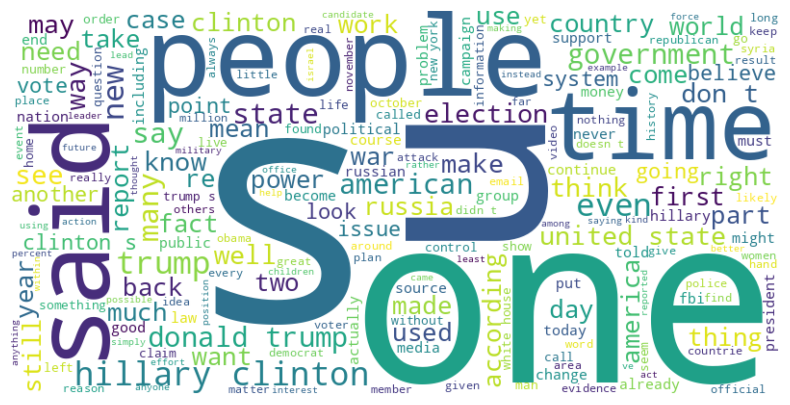

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text from fake news articles
fake_news_text = " ".join(df[df['label'] == 'FAKE']['Clean_text'].astype(str))

# Combine all cleaned text from fake news articles
fake_news_text = " ".join(df[df['label'] == 'FAKE']['Clean_text'].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_news_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show

Word cloud indicating the most frequently used words in fake news and these are, in thier descending order: S>One people>U>said>time>hillary clinton>trump>new etc

4. Text Vectorization (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to top 5000 features

# Fit and transform the cleaned text data from df_cleaned
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned['Clean_text'].astype(str))

# Display the shape of the TF-IDF matrix
print("Shape of TF-IDF matrix:", tfidf_matrix.shape)

# Get Feature Names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
print("TF-IDF Feature Names (first 50):", tfidf_feature_names[:50])

Shape of TF-IDF matrix: (6060, 5000)
TF-IDF Feature Names (first 50): ['10' '100' '1000' '10000' '100000' '11' '12' '1237' '13' '14' '15' '150'
 '16' '17' '18' '19' '1948' '1960s' '1968' '1970s' '1980' '1980s' '1988'
 '1990' '1990s' '1991' '1992' '1993' '1994' '1995' '1996' '1997' '1998'
 '1999' '20' '200' '2000' '20000' '2001' '2002' '2003' '2004' '2005'
 '2006' '2007' '2008' '2009' '2010' '2011' '2012']


 Cleaned text data has been successfully transformed into a numerical matrix with 6060 documents and 5000 features,

**5. MODEL DEVELOPMENT**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features X and y
# Use TF_IDF matix as features and 'label' column as the target
X = tfidf_matrix
y = df_cleaned['label'] # Use the 'label' column from df_cleaned

# Split data into Train and Test Sets
# Usinf Stratify=y to ensure a balanced distribution of labels in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4848, 5000)
Shape of X_test: (1212, 5000)
Shape of y_train: (4848,)
Shape of y_test: (1212,)


The data has been successfully split into training and testing sets, with 80% of the de-duplicated data allocated for training your models and 20% reserved for evaluating how well they perform on unseen data.

### a. Train and Evaluate Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn. metrics import accuracy_score, classification_report

# initialise and train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000) # increased max_iter for convergence
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Model Performance:
Accuracy: 0.9125412541254125
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.89      0.94      0.92       614
        REAL       0.93      0.88      0.91       598

    accuracy                           0.91      1212
   macro avg       0.91      0.91      0.91      1212
weighted avg       0.91      0.91      0.91      1212



###b. Train and Evaluate Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# initialise and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Model Performance:
Accuracy: 0.8993399339933993
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.89      0.92      0.90       614
        REAL       0.91      0.88      0.90       598

    accuracy                           0.90      1212
   macro avg       0.90      0.90      0.90      1212
weighted avg       0.90      0.90      0.90      1212



###c. Train and Evaluate Support Vector Machine (SVM) Model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# initialising to train SVM model using linear kernel(effective for text data)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("Support Vector Machine (SVM) Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Support Vector Machine (SVM) Model Performance:
Accuracy: 0.9207920792079208
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.91      0.93      0.92       614
        REAL       0.93      0.91      0.92       598

    accuracy                           0.92      1212
   macro avg       0.92      0.92      0.92      1212
weighted avg       0.92      0.92      0.92      1212



Based on metrics, Support Vector Machine (SVM) model appears to be the best performer among the three for this dataset and task, showing the highest overall accuracy and generally strong precision, recall, and F1-scores for both FAKE and REAL classes. Logistic Regression is a close second, particularly strong in recall for the FAKE class. Random Forest, while still performing well, has slightly lower scores across most metrics compared to the other two.

**6. HYPERPARAMETER TUNING**

a. Logistic Regression Hyperparameter Tuning

In [ ]:
from sklearn. model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Defining the parameter grid to search (tune 'C' Regularisation strength and penalty L1 or L2 regularisation)
param_grid_lr = {
    'C': [0.1, 1.0, 10.0, 100.0], # Inverse of regularization strength
    'penalty': ['l2'] # L2 penalty is standard for Logistic Regression with 'liblinear
    # adding other parameters if needed eg, 'solver': [liblinear', saga]
}

# initialisation of GridSearchCH (using accuracy as scoring matric andusing cross-validation (cv=5)
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)

# perform the grid search on the training data
print("Performing Grid Search for Logistic Regression...")
grid_search_lr.fit(X_train, y_train)
print("Grid Search complete.")

# Evaluating the best model on test data
best_lr_model = grid_search_lr.best_estimator_
y_pred_tuned_lr = best_lr_model.predict(X_test)
print("\nTuned Logistic Regression Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned_lr))

Performing Grid Search for Logistic Regression...
Grid Search complete.

Tuned Logistic Regression Model Performance on Test Set:
Accuracy: 0.9249174917491749
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.91      0.94      0.93       614
        REAL       0.94      0.91      0.92       598

    accuracy                           0.92      1212
   macro avg       0.93      0.92      0.92      1212
weighted avg       0.93      0.92      0.92      1212



Untuned Accuracy: 0.9125
Tuned Accuracy: 0.9249
Improvement: tuning led to an increase in overall accuracy and generally improved F1-scores for both classes.

b. Random Forest Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Defining the parameter grid to search for Random forest using n_estimators, max_depth, min_samples_split, min_samples_leaf
param_grid_rf = {
    'n_estimators': [100, 200], # Number of trees in the forest
    'max_depth': [10, 20, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5], # Minimum number of samples required to split and internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
    # Consider adding 'criterion': ['gini', 'entropy'] if needed, but start simple
}

# Initialising GridSearchCV for Random Forest using accuracy as scoring metric and croo-validation (cv=3 for faster tuning)
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)

# Perform the grid search on the training data
print("Performing Grid Search for Random Forest...")
grid_search_rf.fit(X_train, y_train)
print("Grid Search complete.")

# print best parameter and best score
print("\nBest parameters found:", grid_search_rf.best_params_)
print("Best cross-validation accuracy:", grid_search_rf.best_score_)

# Evaluate best model on test data
best_rf_model = grid_search_rf.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test)

print("\nTuned Random Forest Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned_rf))


Performing Grid Search for Random Forest...
Grid Search complete.

Best parameters found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.9057343234323433

Tuned Random Forest Model Performance on Test Set:
Accuracy: 0.9018151815181518
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.90      0.91      0.90       614
        REAL       0.90      0.90      0.90       598

    accuracy                           0.90      1212
   macro avg       0.90      0.90      0.90      1212
weighted avg       0.90      0.90      0.90      1212



Tuned Random Forest:

Untuned Accuracy: 0.8993
Tuned Accuracy: 0.9018
Improvement:tuning resulted in a slight increase in overall accuracy and minor changes in class-specific metrics.

c. SVM Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid to search for SVM; use tune 'C' parameter(regularisation Parameter)
param_grid_svm = {
    'C': [0.1, 1.0, 10.0, 100.0], # Regularization parameter
    'kernel': ['linear'] # We'll focus on the linear kernel as it performed well initially

}

# Initialize GridSearchCV for SVM
# We'll use accuracy as the scoring metric and use cross-validation (cv=3 for faster tuning)
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)

# Perform the grid search on the training data
print("Performing Grid Search for Support Vector Machine (SVM)...")
grid_search_svm.fit(X_train, y_train)
print("Grid Search complete.")

# Print the best parameters and best score
print("\nBest parameters found:", grid_search_svm.best_params_)
print("Best cross-validation accuracy:", grid_search_svm.best_score_)

# Evaluate the best model on the test data
best_svm_model = grid_search_svm.best_estimator_
y_pred_tuned_svm = best_svm_model.predict(X_test)

print("\nTuned Support Vector Machine (SVM) Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned_svm))

Performing Grid Search for Support Vector Machine (SVM)...
Grid Search complete.

Best parameters found: {'C': 1.0, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9267739273927393

Tuned Support Vector Machine (SVM) Model Performance on Test Set:
Accuracy: 0.9207920792079208
Classification Report:
               precision    recall  f1-score   support

        FAKE       0.91      0.93      0.92       614
        REAL       0.93      0.91      0.92       598

    accuracy                           0.92      1212
   macro avg       0.92      0.92      0.92      1212
weighted avg       0.92      0.92      0.92      1212



Support Vector Machine (SVM):
Untuned Accuracy: 0.9208
Tuned Accuracy: 0.9208
Improvement: No significant change in overall accuracy or class-specific metrics with the chosen parameter grid.

Summary of Perfromance of Tunned Models.

In summary, hyperparameter tuning resulted in a notable improvement for the Logistic Regression model and a slight improvement for the Random Forest model, while the chosen tuning parameters for SVM did not yield a significant change in performance on the test set.

8. **FEATURE IMPORTANCE**

In [ ]:
import pandas as pd

# Get Feature importances from Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from TF-IDF vectorizer
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out() # Correct variable name

# Create a DataFrame to view features importances
features_df = pd.DataFrame({'feature': tfidf_feature_names, 'importance': feature_importances})

# Sorting features in descending order of importance
features_df = features_df.sort_values(by='importance', ascending=False)

# Display the top N most important features
top_n = 25
print(f"Top {top_n} most important features from Random Forest model:")
display(features_df.head(top_n))

Top 25 most important features from Random Forest model:


,feature,importance
3917,said,0.020932
3771,republican,0.017385
4008,sen,0.014760
53,2016,0.014062
1994,gop,0.012521
3088,october,0.010463
1160,cruz,0.008237
3432,president,0.007613
1998,gov,0.007041
4459,ted,0.007006


7. Save Model and Vectorizer

In [ ]:
import joblib
import os

# Define file paths for saving the models and vectorizer
model_filename_lr = 'tuned_logistic_regression_fake_news_detector_model.joblib'
model_filename_svm = 'tuned_svm_fake_news_detector_model.joblib'
vectorizer_filename = 'tfidf_vectorizer.joblib'

# Save the trained tuned Logistic Regression model
# Ensure best_lr_model is defined
joblib.dump(best_lr_model, model_filename_lr)
print(f"Tuned Logistic Regression model saved to {model_filename_lr}")

# Save the trained tuned SVM model
# Ensure best_svm_model is defined
joblib.dump(best_svm_model, model_filename_svm)
print(f"Tuned SVM model saved to {model_filename_svm}")

# Save the fitted TF-IDF vectorizer
# Ensure tfidf_vectorizer is defined
joblib.dump(tfidf_vectorizer, vectorizer_filename)
print(f"TF-IDF vectorizer saved to {vectorizer_filename}")

# You can list the saved files to confirm
print("\nSaved files:")
!ls *.joblib

Tuned Logistic Regression model saved to tuned_logistic_regression_fake_news_detector_model.joblib
Tuned SVM model saved to tuned_svm_fake_news_detector_model.joblib
TF-IDF vectorizer saved to tfidf_vectorizer.joblib

Saved files:
tfidf_vectorizer.joblib
tuned_logistic_regression_fake_news_detector_model.joblib
tuned_svm_fake_news_detector_model.joblib


## Key Insights and Recommendations


This project focused on detecting fake news using a machine learning approach. Key findings and recommendations are summarized below:

Dataset Insights:
The dataset had a balanced distribution of fake and real news, ideal for training. Duplicate entries were identified and removed to create a cleaner dataset. Preprocessing steps—such as lowercasing, stopword removal, and punctuation cleaning—enabled creation of a refined Clean_text column. Preliminary analysis, including sentiment and length metrics, helped contextualize the data.

Feature Engineering & Modeling:
TF-IDF transformed the text into a usable numerical format (606 x 500). Key terms were identified through feature importance analysis, providing insight into the language used in fake vs real news.
Three models were evaluated:

Support Vector Machine (SVM): Highest accuracy at 92.08%

Logistic Regression: Improved significantly after tuning

Random Forest: Slight performance improvement
Logistic Regression was selected for future deployment due to its post-tuning gains.

Ethical Risks Identified:

Bias in training data can propagate misinformation.

Lack of human judgment may result in suppression of valid or minority voices.

Echo chambers may reinforce user biases and hinder exposure to diverse viewpoints.

Recommendations:

Incorporate metadata like source credibility and engagement metrics.

Use user feedback loops to enhance transparency.

Implement robust strategies to detect and reduce data/model bias.

Challenges Faced:
The dataset’s poor structure—despite being in CSV format—complicated data cleaning and required extensive preprocessing.
edited:chatgpt

